In [3]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 2.3 MB/s eta 0:00:44
   ---------------------------------------- 0.8/101.7 MB 1.6 MB/s eta 0:01:04
    --------------------------------------- 1.3/101.7 MB 1.7 MB/s eta 0:01:01
    --------------------------------------- 1.3/101.7 MB 1.7 MB/s eta 0:01:01
    --------------------------------------- 1.8/101.7 MB 1.5 MB/s eta 0:01:07
    --------------------------------------- 2.1/101.7 MB 1.5 MB/s eta 0:01:06
    --------------------------------------- 2.4/101.7 MB 1.5 MB/s eta 0:01:08
   - -------------------------------------- 2.9/101.7 MB 1.6 MB/s eta 0:01:02
   - -------------------------------------- 3.1/101.7 MB 1.6 MB/s eta 0:01:03
   - -------------------------------------- 3.4/101.7 MB 1.6 MB/s eta 0:01:00
   - --

In [4]:
X_train = pd.read_csv('X_train.csv')
X_test  = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test  = pd.read_csv('y_test.csv')

y_train = y_train.values.ravel()
y_test  = y_test.values.ravel()

print('Data loaded successfully!')
print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape, '| Class dist:', dict(zip(*np.unique(y_train, return_counts=True))))
print('y_test :', y_test.shape,  '| Class dist:', dict(zip(*np.unique(y_test,  return_counts=True))))

Data loaded successfully!
X_train: (9592, 9)
X_test : (2399, 9)
y_train: (9592,) | Class dist: {np.int64(0): np.int64(7999), np.int64(1): np.int64(1593)}
y_test : (2399,) | Class dist: {np.int64(0): np.int64(2001), np.int64(1): np.int64(398)}


In [5]:
X_train = pd.get_dummies(X_train)
X_test  = pd.get_dummies(X_test)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print('After encoding:')
print('X_train:', X_train.shape)
print('X_test :', X_test.shape)

After encoding:
X_train: (9592, 20)
X_test : (2399, 20)


In [6]:
neg = np.sum(y_train == 0)   
pos = np.sum(y_train == 1)  

scale_pos_weight = neg / pos

print(f'Stayed (0): {neg}')
print(f'Left   (1): {pos}')
print(f'Imbalance ratio: {scale_pos_weight:.2f}')
print(f'scale_pos_weight = {scale_pos_weight:.2f}  (will be passed to XGBClassifier)')

Stayed (0): 7999
Left   (1): 1593
Imbalance ratio: 5.02
scale_pos_weight = 5.02  (will be passed to XGBClassifier)


In [7]:
xgb = XGBClassifier(
    objective         = 'binary:logistic',  
    eval_metric       = 'auc',             
    scale_pos_weight  = scale_pos_weight,   
    use_label_encoder = False,
    random_state      = 0,
    n_jobs            = -1                  
)

param_distributions = {
    'n_estimators'      : [100, 200, 300, 500],   
    'max_depth'         : [3, 4, 5, 6, 8],         
    'learning_rate'     : [0.01, 0.05, 0.1, 0.2], 
    'subsample'         : [0.6, 0.7, 0.8, 1.0],   
    'colsample_bytree'  : [0.6, 0.7, 0.8, 1.0],   
    'min_child_weight'  : [1, 3, 5],               
    'gamma'             : [0, 0.1, 0.2, 0.5]       
}

total_combos = 4*5*4*4*4*3*4
print(f'Total possible combinations: {total_combos}')
print('RandomizedSearchCV will sample only: 20 (n_iter=20)')

Total possible combinations: 15360
RandomizedSearchCV will sample only: 20 (n_iter=20)


In [8]:
xgb_cv = RandomizedSearchCV(
    estimator           = xgb,
    param_distributions = param_distributions,
    n_iter              = 20,        
    scoring             = 'roc_auc', 
    cv                  = 4,         
    refit               = True,      
    random_state        = 0,
    n_jobs              = -1,        
    verbose             = 1          
)

print('XGBoost RandomizedSearchCV configured.')
print('Total fits = 20 combos x 4 folds =', 80)

XGBoost RandomizedSearchCV configured.
Total fits = 20 combos x 4 folds = 80


In [9]:
start_time = time.time()

xgb_cv.fit(X_train, y_train)

end_time = time.time()
elapsed = end_time - start_time

print(f'\nTraining Time: {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)')
print('\nBest Parameters Found:')
for param, value in xgb_cv.best_params_.items():
    print(f'  {param}: {value}')
print(f'\nBest CV ROC-AUC Score: {xgb_cv.best_score_:.4f}')

Fitting 4 folds for each of 20 candidates, totalling 80 fits


C:\Users\vidha\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:43:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Training Time: 27.19 seconds (0.45 minutes)

Best Parameters Found:
  subsample: 0.7
  n_estimators: 200
  min_child_weight: 1
  max_depth: 3
  learning_rate: 0.05
  gamma: 0.2
  colsample_bytree: 0.8

Best CV ROC-AUC Score: 0.9853


In [10]:
# Best model
best_xgb = xgb_cv.best_estimator_

# Predictions
y_pred       = best_xgb.predict(X_test)
y_pred_proba = best_xgb.predict_proba(X_test)[:, 1]

# Metrics
acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc       = roc_auc_score(y_test, y_pred_proba)

print('=' * 42)
print('        XGBoost — TEST SET METRICS')
print('=' * 42)
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  F1 Score  : {f1:.4f}')
print(f'  ROC-AUC   : {auc:.4f}')
print('=' * 42)

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Stayed (0)', 'Left (1)']))

        XGBoost — TEST SET METRICS
  Accuracy  : 0.9675
  Precision : 0.8721
  Recall    : 0.9422
  F1 Score  : 0.9058
  ROC-AUC   : 0.9885

Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.99      0.97      0.98      2001
    Left (1)       0.87      0.94      0.91       398

    accuracy                           0.97      2399
   macro avg       0.93      0.96      0.94      2399
weighted avg       0.97      0.97      0.97      2399



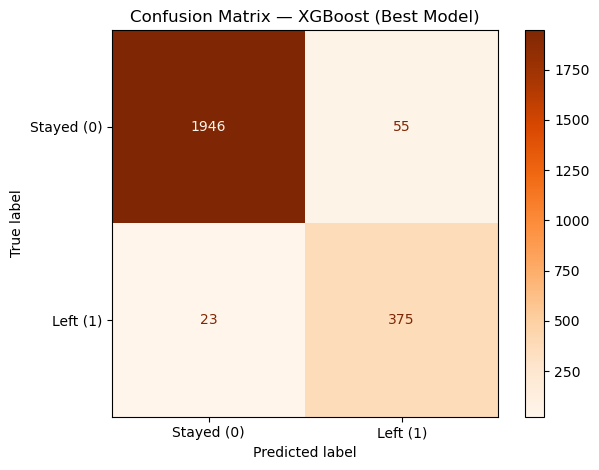

Confusion matrix saved as xgb_confusion_matrix.png


In [11]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels   = ['Stayed (0)', 'Left (1)']
)
disp.plot(cmap='Oranges')
plt.title('Confusion Matrix — XGBoost (Best Model)')
plt.tight_layout()
plt.savefig('xgb_confusion_matrix.png', dpi=150)
plt.show()
print('Confusion matrix saved as xgb_confusion_matrix.png')

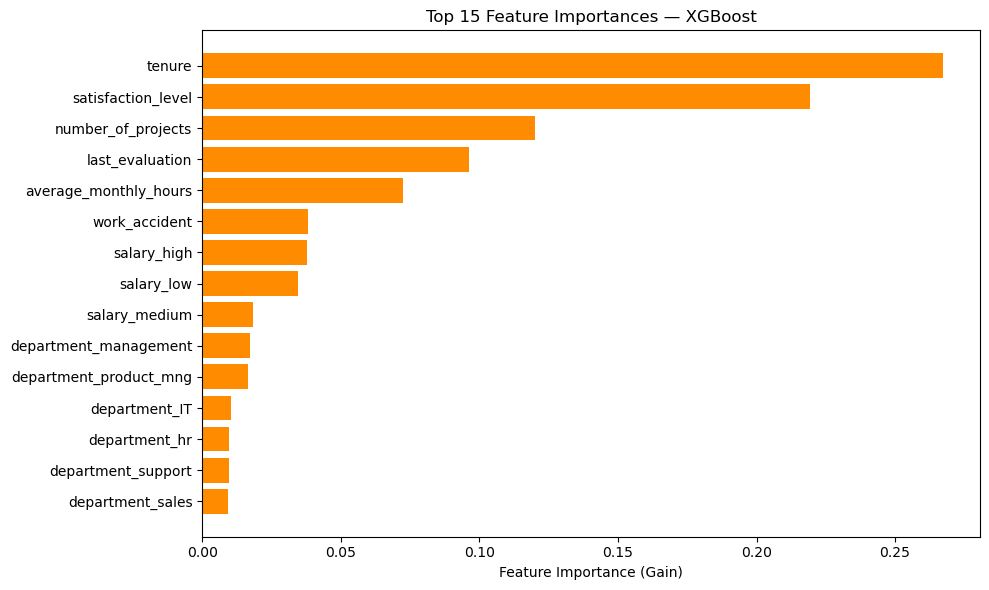


Top 15 Features:
               Feature  Importance
                tenure    0.267273
    satisfaction_level    0.219255
    number_of_projects    0.120075
       last_evaluation    0.096159
 average_monthly_hours    0.072428
         work_accident    0.038332
           salary_high    0.037737
            salary_low    0.034489
         salary_medium    0.018281
 department_management    0.017275
department_product_mng    0.016341
         department_IT    0.010293
         department_hr    0.009529
    department_support    0.009500
      department_sales    0.009255


In [12]:
importances   = best_xgb.feature_importances_
feature_names = X_train.columns

feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(feat_df['Feature'][::-1], feat_df['Importance'][::-1], color='darkorange')
plt.xlabel('Feature Importance (Gain)')
plt.title('Top 15 Feature Importances — XGBoost')
plt.tight_layout()
plt.savefig('xgb_feature_importances.png', dpi=150)
plt.show()

print('\nTop 15 Features:')
print(feat_df.to_string(index=False))

In [13]:
cv_results = pd.DataFrame(xgb_cv.cv_results_)

cols = [
    'rank_test_score', 'mean_test_score', 'std_test_score',
    'param_n_estimators', 'param_max_depth', 'param_learning_rate',
    'param_subsample', 'param_colsample_bytree',
    'param_min_child_weight', 'param_gamma'
]

top5 = cv_results[cols].sort_values('rank_test_score').head(5)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print('Top 5 Hyperparameter Combinations by ROC-AUC:')
print(top5.to_string(index=False))

Top 5 Hyperparameter Combinations by ROC-AUC:
 rank_test_score  mean_test_score  std_test_score  param_n_estimators  param_max_depth  param_learning_rate  param_subsample  param_colsample_bytree  param_min_child_weight  param_gamma
               1         0.985266        0.001757                 200                3                 0.05              0.7                     0.8                       1          0.2
               2         0.985239        0.001350                 300                3                 0.05              0.8                     1.0                       1          0.5
               3         0.985129        0.001128                 100                5                 0.10              1.0                     1.0                       1          0.2
               4         0.985123        0.002774                 500                8                 0.01              1.0                     0.8                       5          0.5
               5        